## Linear Regression: Baseline Model

### Exploratory Data Analysis

In [3]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import joblib

from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [4]:
# Load data in dataframe
train_student_data = pd.read_csv("../data/train.csv")
test_student_data = pd.read_csv("../data/test.csv")

train_student_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
train_student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [6]:
# Drop ID column (redundant)
id_data = test_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
test_student_data = test_student_data.drop(columns=["id"])

# Explore all unique values for categorical features

print("Unique Gender:", train_student_data["gender"].unique())
print("Unique Course:", train_student_data["course"].unique())
print("Unique Internet Access:", train_student_data["internet_access"].unique())
print("Sleep Quality:", train_student_data["sleep_quality"].unique())
print("Study Method:", train_student_data["study_method"].unique())
print("Facility Rating:", train_student_data["facility_rating"].unique())
print("Exam Difficulty:", train_student_data["exam_difficulty"].unique())

Unique Gender: ['female' 'other' 'male']
Unique Course: ['b.sc' 'diploma' 'bca' 'b.com' 'ba' 'bba' 'b.tech']
Unique Internet Access: ['no' 'yes']
Sleep Quality: ['average' 'poor' 'good']
Study Method: ['online videos' 'self-study' 'coaching' 'group study' 'mixed']
Facility Rating: ['low' 'medium' 'high']
Exam Difficulty: ['easy' 'moderate' 'hard']


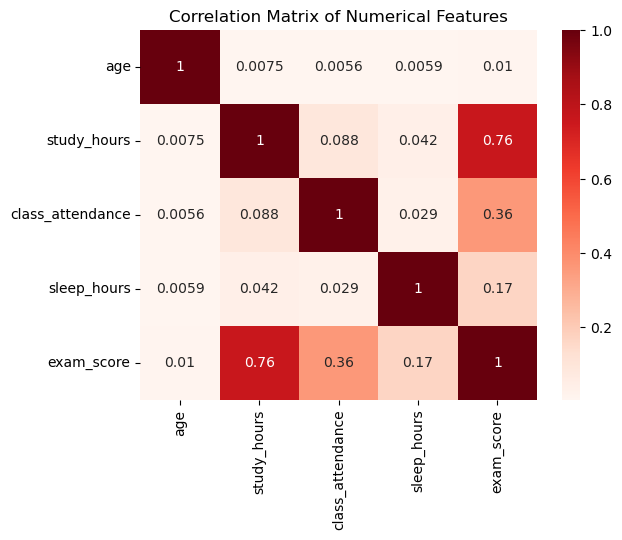

In [7]:
# Analyze correlation between numerical features
numerical_features = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
corr_matrix = train_student_data[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Reds")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [8]:
# Make Internet Access Binary (Yes = 1, No =0)
train_student_data["internet_access"] = train_student_data["internet_access"].map({"yes": 1, "no": 0})
test_student_data["internet_access"] = test_student_data["internet_access"].map({"yes": 1, "no": 0})    

# One Hot Encode remaining categorical features

categorical_features = ["gender","course","sleep_quality","study_method","facility_rating","exam_difficulty"]
one_hot_data = train_student_data[categorical_features]

encoder = OneHotEncoder(drop="first", sparse_output=False) # Avoid multicollinearity

one_hot_encoded = encoder.fit_transform(one_hot_data)
one_hot_names = encoder.get_feature_names_out(categorical_features)

# Replace existing categorical rows
train_student_data = pd.concat(
    [train_student_data.drop(columns=categorical_features), pd.DataFrame(one_hot_encoded, columns=one_hot_names)],
    axis=1
)

test_student_data = pd.concat(
    [test_student_data.drop(columns=categorical_features), pd.DataFrame(encoder.transform(test_student_data[categorical_features]), columns=one_hot_names)],
    axis=1
)

# View all hot encoded categorical features (for viewing)
print(one_hot_names)

['gender_male' 'gender_other' 'course_b.sc' 'course_b.tech' 'course_ba'
 'course_bba' 'course_bca' 'course_diploma' 'sleep_quality_good'
 'sleep_quality_poor' 'study_method_group study' 'study_method_mixed'
 'study_method_online videos' 'study_method_self-study'
 'facility_rating_low' 'facility_rating_medium' 'exam_difficulty_hard'
 'exam_difficulty_moderate']


In [9]:
# Print new dataframe
train_student_data.head()

,age,study_hours,class_attendance,internet_access,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,21,7.91,98.8,0,4.9,78.3,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,18,4.95,94.8,1,4.7,46.7,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,20,4.68,92.6,1,5.8,99.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,19,2.00,49.5,1,8.3,63.9,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,23,7.65,86.9,1,9.6,100.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Train Linear Regression

In [16]:
# Remove target feature from feature list
target = "exam_score"

features = list(train_student_data.columns)
features.remove(target)

X = train_student_data[features]
y = train_student_data[target]

X_submission = test_student_data[features]

# Split training data into train/validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train on linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Print Linear Regression Coefficients
print("Intercept:", lin_reg.intercept_)
pd.DataFrame(lin_reg.coef_, features, columns = ["Coefficient"])

Intercept: 62.48233479761903


,Coefficient
age,-0.027986
study_hours,13.398210
class_attendance,5.452808
internet_access,-0.000984
sleep_hours,2.308319
gender_male,-0.054738
gender_other,0.094815
course_b.sc,-0.056069
course_b.tech,0.088016
course_ba,-0.005300


### Evaluate

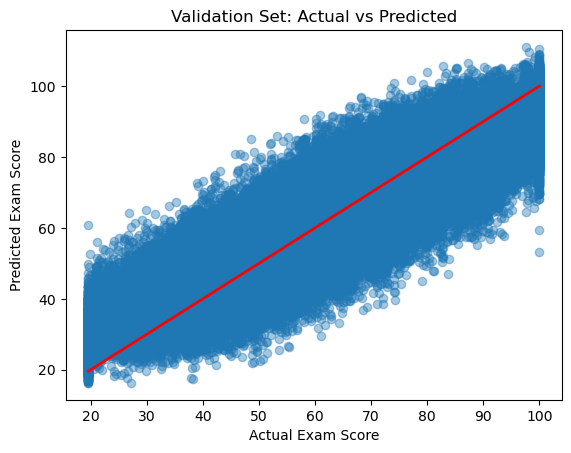

In [17]:
# Evaluate model performance (validation data)
y_val_pred = lin_reg.predict(X_val_scaled)

# Graph actual vs predicted in scatter plot
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r', lw=2) 

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted")
plt.show()

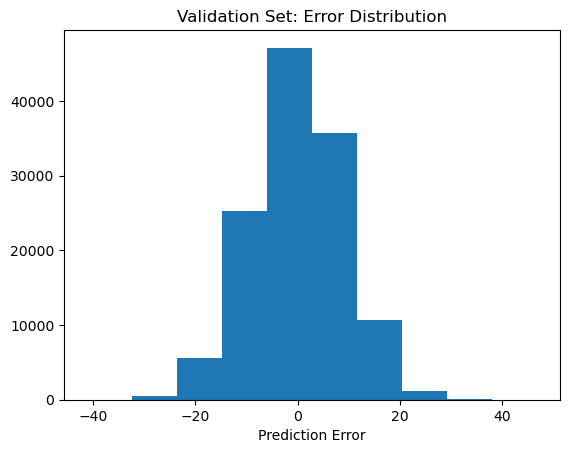

In [18]:
plt.hist(y_val - y_val_pred)
plt.xlabel("Prediction Error")
plt.title("Validation Set: Error Distribution")
plt.show()

In [ ]:
# Regression Model Evaluation Metrics (validation data)

res_metrics = pd.DataFrame({
  "MAE": [metrics.mean_absolute_error(y_val, y_val_pred)],
  "MSE": [metrics.mean_squared_error(y_val, y_val_pred)],
  "RMSE": [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
  "R2": [metrics.r2_score(y_val, y_val_pred)] 
})

pd.set_option("float_format", "{:f}".format)
# res_metrics.to_csv("../metrics/linear_regression_metrics.csv", index=False)
print("Metrics saved to ../metrics/linear_regression_metrics.csv")
res_metrics

Metrics saved to ../metrics/linear_regression_metrics.csv


,MAE,MSE,RMSE,R2
0,7.093260,78.969714,8.886491,0.777955


### Applying Cross Validation

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, KFold

X = train_student_data[features]
y = train_student_data[target]

cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# 5 Fold Cross Validation
cv = KFold(n_splits=5, shuffle=True, random_state=0)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

scores = cross_validate(cv_model, X, y, cv=cv, scoring=scoring)

res_cv_metrics = pd.DataFrame({
    "MAE": [-scores["test_MAE"].mean()],
    "MSE": [-scores["test_MSE"].mean()],
    "RMSE": [-scores["test_RMSE"].mean()],
    "R2": [scores["test_R2"].mean()]
})

print("Cross-Validation Metrics:")
print(res_cv_metrics)

# Fit pipeline on full training data to get coefficients
cv_model.fit(X, y)

# Extract coefficients from the regressor inside the pipeline
regressor = cv_model.named_steps['regressor']

Cross-Validation Metrics:
       MAE       MSE     RMSE       R2
0 7.101323 79.117378 8.894786 0.778904


In [22]:
print("\nIntercept:", regressor.intercept_)
pd.DataFrame(regressor.coef_, features, columns=["Coefficient"])


Intercept: 62.506672165079365


,Coefficient
age,-0.030963
study_hours,13.395767
class_attendance,5.442616
internet_access,0.006351
sleep_hours,2.306111
gender_male,-0.049755
gender_other,0.089957
course_b.sc,-0.067900
course_b.tech,0.067826
course_ba,-0.009901


### Generate Submission

In [ ]:
# Generate submission predictions using scaled test set
X_submission_scaled = scaler.transform(X_submission)
exam_score = lin_reg.predict(X_submission_scaled)

df_lr = pd.DataFrame({
    "id": id_data,
    "exam_score": exam_score
})
df_lr.to_csv("../output csv/linear_regression_submission.csv", index=False)
print("Submission saved to ../output csv/linear_regression_submission.csv")
df_lr


# Generate submission predictions using cross validated model
exam_score_cv = cv_model.predict(X_submission)

df_lr_cv = pd.DataFrame({
    "id": id_data,
    "exam_score": exam_score
})
df_lr_cv.to_csv("../output csv/linear_regression_cv_submission.csv", index=False)
print("Submission saved to ../output csv/linear_regression_cv_submission.csv")
df_lr_cv

Submission saved to ../submission/linear_regression_submission.csv
Submission saved to ../output csv/linear_regression_cv_submission.csv


,id,exam_score
0,630000,71.759754
1,630001,69.478246
2,630002,87.469780
3,630003,54.938523
4,630004,47.301788
...,...,...
269995,899995,60.947791
269996,899996,38.887484
269997,899997,89.947095
269998,899998,55.479250


In [ ]:
# Save model
joblib.dump(lin_reg, "../models/initial_linear_regression.pkl")
print("Model saved to ../models/initial_linear_regression.pkl")

Model saved to ../models/initial_linear_regression.pkl
